In [2]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, cross_val_score
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score, 
    accuracy_score, 
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score, 
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn as nn
import torch.optim as optim

## 1. Загрузка изображений

In [4]:
def load_mnist_local(image_file, label_file):
    """ 
        Загружает данные. Преобразуя в массивы numpy
    """
    with open(image_file, 'rb') as f:
        images = np.frombuffer(f.read(), np.uint8, offset=16)
        images = images.reshape(-1, 28*28)
    with open(label_file, 'rb') as f:
        labels = np.frombuffer(f.read(), np.uint8, offset=8)
    return images, labels

X, y = load_mnist_local('t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte')

In [37]:
# Приводим значения пикселей в MNIST к диапазону от -1 до 1
X = ((X / 255.) - .5) * 2

## Eda

In [5]:
X.shape # размерность массива

(10000, 784)

In [6]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

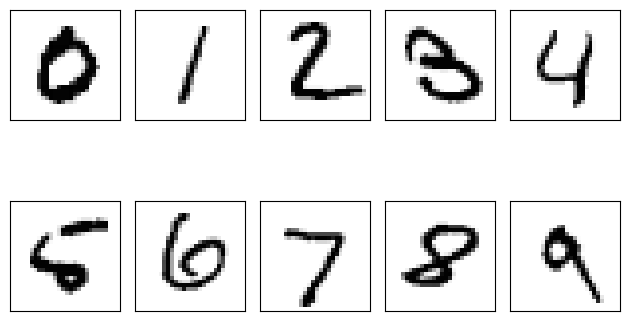

In [7]:
# Визуализируем цифры, как матрицы
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [10]:
count_target = np.bincount(y) # подсчитываем кол-во записей для каждой метки в таргет
count_target

array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009])

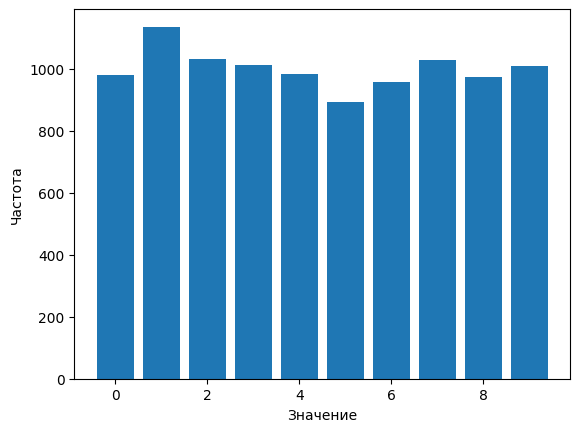

In [15]:
plt.bar(np.arange(len(count_target)), count_target)
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

Видим, что значения не сильно отклоняются друг от друга. Для всех меток значение находится в диапазоне от 850 до 1150

## 2. Сегментация

In [20]:
target = y.astype(np.int64)

target = np.where(target == 4, 1, 0) # переводим класс четверки в 1, остальные 0

тк у нас уже имеются метки классов, просто преобразуем эти данные под наш случай

In [21]:
target 

array([0, 0, 0, ..., 1, 0, 0])

In [22]:
np.bincount(target)

array([9018,  982])

видим несбалансированный таргет. Для 0 - это 9018 записей, для 1 - 982 записей.

## 3. Разделить данные на тренировочную и тестовую

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.3, random_state=1, stratify=y
) # используем стратификацию по таргету для балансировки классов

In [25]:
X_train.shape, y_train.shape # размерность X

((7000, 784), (7000,))

In [26]:
X_test.shape, y_test.shape   # размерность y

((3000, 784), (3000,))

## 4. Обучить модель на нахождение "4"

Возьмем в качестве baseline логистическую регрессию.

In [27]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # проведем кросс валидацию с оценкой по f1

scores = cross_val_score(lr, X_train, y_train, cv=skf, scoring="f1")
scores

array([0.83636364, 0.89130435, 0.8975265 , 0.84782609, 0.82437276])

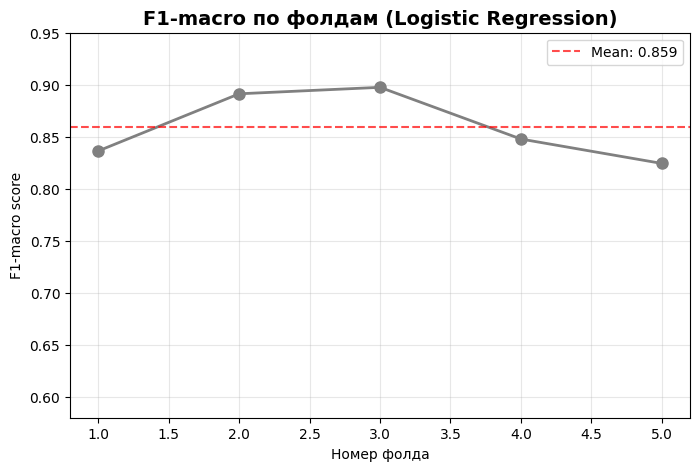

In [30]:
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, scores, marker='o', linewidth=2, markersize=8, color='gray')
plt.axhline(y=np.mean(scores), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(scores):.3f}')

plt.title('F1-macro по фолдам (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Номер фолда')
plt.ylabel('F1-macro score')
plt.ylim(0.58, 0.95)
plt.grid(True, alpha=0.3)
plt.legend()

Наблюдаем среднюю оценку 0.86

## 5. Проверить результат на тест выборке

In [55]:
train_score = lr.score(bX_train, by_train)
test_score = lr.score(bX_test, by_test)

(round(train_score, 3), round(test_score, 3))

(0.994, 0.974)

Проверим модель на under/over fitting. Заметим, оба значения близки к 1

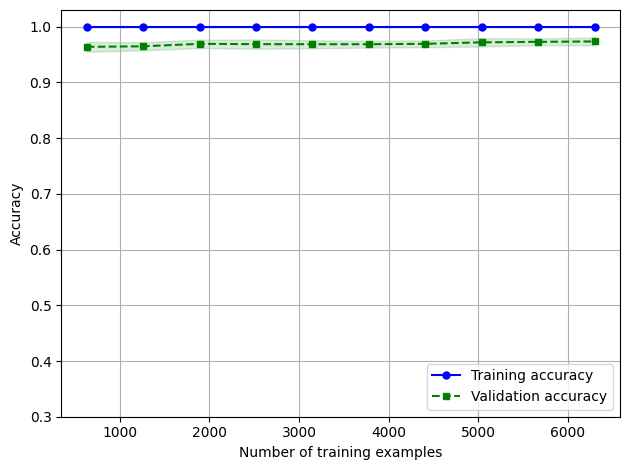

In [32]:
train_sizes, train_scores, test_scores =\
                learning_curve(estimator=lr,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.3, 1.03])
plt.tight_layout()
plt.show()

Наблюдаем, что модель имеет хороший компромисс между смещением и дисперсией.

Модель хорошо объясняет обучающие данные. И хорошо обобщает новые данные

## 6. Оценить результат метрик

In [33]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
pr = precision_score(y_test, y_pred)
Re = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

In [58]:
print(f"Accuracy - {round(acc, 3)}\nPrecision - {round(pr, 3)}\nRecall - {round(Re, 3)}\nF1 score - {round(f1, 3)}\nROC-Auc - {round(roc_auc, 3)}")

Accuracy - 0.974
Precision - 0.882
Recall - 0.854
F1 score - 0.868
ROC-Auc - 0.921


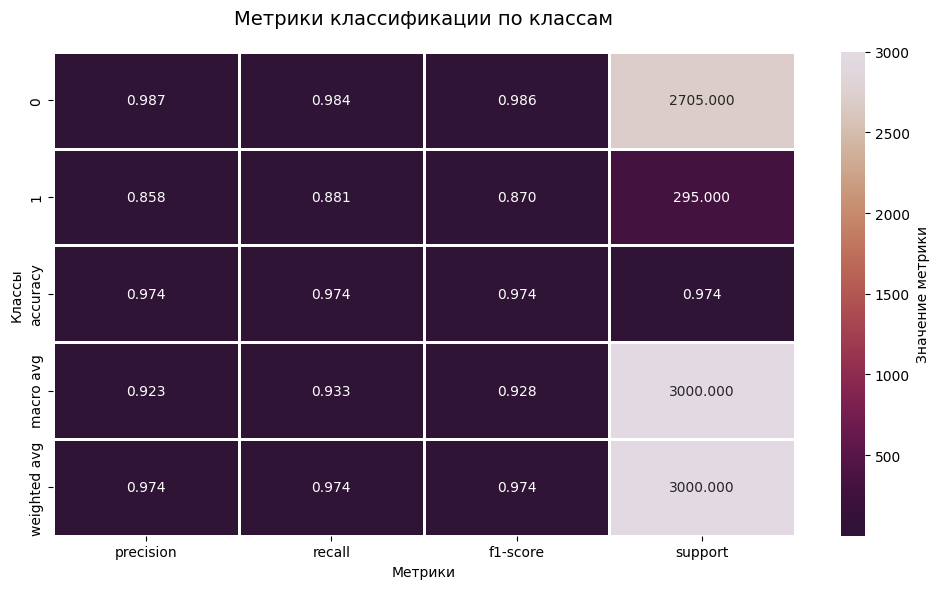

In [37]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, 
            annot=True, 
            fmt='.3f', 
            cmap='twilight',
            center=0.5,
            linewidths=1,
            cbar_kws={'label': 'Значение метрики'})

plt.title('Метрики классификации по классам', fontsize=14, pad=20)
plt.xlabel('Метрики')
plt.ylabel('Классы')
plt.tight_layout()
plt.show()

Мы видим, что метрики стремятся к 1. И находятся в диапазоне от 0.85 до 1

Можем отметить, что метрика по предсказанию 0 класса замечательная. Но 1 класс можно дообучить или затюнить машину на лучшую классификацию

## 7. Начертить графики Pr/Re и Roc-Auc

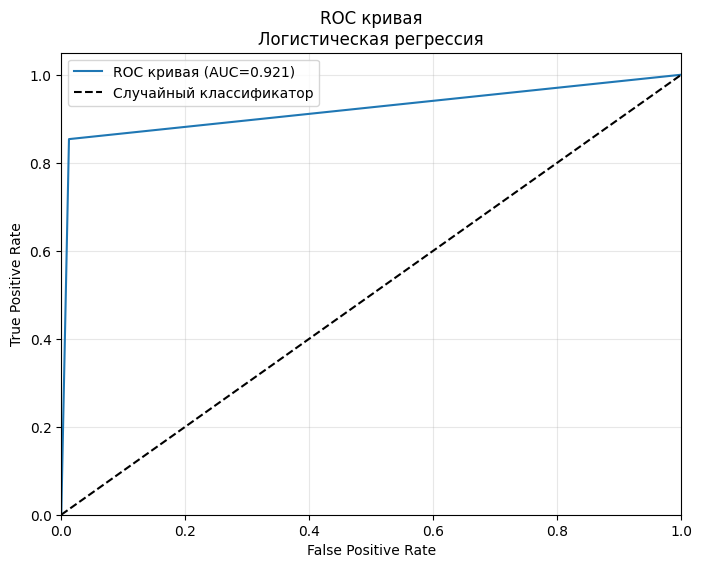

In [63]:
plt.figure(figsize=(8, 6))
fpr, tpr, roc_thresholds = roc_curve(by_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC кривая (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая\nЛогистическая регрессия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

По графику Roc-Auc можем интерпритировать: Оценка отличая, модель имеет качество "идеальная"

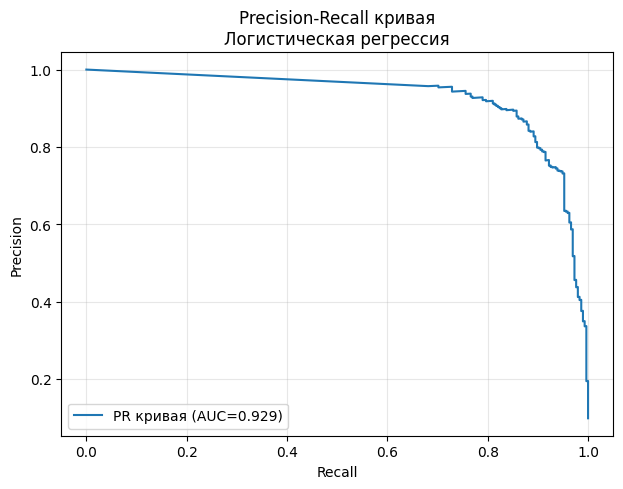

In [40]:
plt.figure(figsize=(12, 5))

# Precision-Recall
plt.subplot(1, 2, 1)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR кривая (AUC={pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая\nЛогистическая регрессия')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Также, по Pr и Re также, отметим, что модель довольно реалистичная

## 8. Оценить результаты каждой метрики

Accuracy(0.974) - в нашем случае плохая метрика. Тк наш таргет несбалансирован. Будет высокий скор от мажоритарного класса. Недостаток: Не работает на несбалансированных данных

Precision(0.882) - по отдельности данной метрики не хватит для корректной оценки модели. Недостаток: Игнорирует ложноотрицательные ошибки 

Recall(0.854) - по отдельности данной метрики не хватит для корректной оценки модели. Недостаток: Не учитывает ложноположительные ошибки 

F1 score(0.868) - это баланс между precision/recall, применятеся для несбалансировынных выборок. Недостаток: Менее интерпретируема чем отдельные метрики

ROC-Auc(0.921) - кривая рабочих характеристик приемника

Можем полагаться на совокупность метрик Pr, Re, F1, Roc. По ним видим, что имеет скор в 0.868 и 0.92 отличная дискриминационная способность. Качество модели в таком случае довольно хорошее.

## 9. Model optim

Тк наша baseline модель и так уже хороша, то прибегать к другим методам классификации не требуется. Можем лишь подтюнить параметры модели.

Но тем не менее посмотрим, что полутся при использовании глубокого обучения.

In [48]:
class TestMNIST(Dataset):
    """
        PyTorch Dataset для бинарной классификации цифры 4 в MNIST.
    
        Преобразует сырые .ubyte файлы MNIST в нормализованные изображения 28x28
        и метки (1.0 для цифры 4, 0.0 для остальных).
    """
    def __init__(self, image_file, label_file, transform=None):
        with open(image_file, 'rb') as f:
            images = np.frombuffer(f.read(), np.uint8, offset=16)
            self.images = images.reshape(-1, 28, 28).astype(np.float32) / 255.0
        
        with open(label_file, 'rb') as f:
            self.labels = np.frombuffer(f.read(), np.uint8, offset=8)
        
        # Бинарная классификация
        self.labels = np.where(self.labels == 4, 1.0, 0.0).astype(np.float32)
        
        self.transform = transform
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        img = Image.fromarray((self.images[idx] * 255).astype(np.uint8))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [49]:
transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize((0.1307,), (0.3081,))])

test_dataset = TestMNIST(
    image_file='t10k-images.idx3-ubyte',
    label_file='t10k-labels.idx1-ubyte',
    transform=transform
)

In [50]:
train_size = int(0.7 * len(test_dataset))
valid_size = len(test_dataset) - train_size
# делим 70 на 30, подготавливаем валид и трейн датасеты с бачами 64
train_dataset, valid_dataset = random_split(test_dataset, [train_size, valid_size])

batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(valid_dataset, batch_size, shuffle=False)

In [51]:
class BinaryMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
# подготовили нашу сеть с: полносвязным слоем, активацией relu, прореживанием, на выходе сигмоидная активация
# forwars pass возьмем как flatten
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [52]:
pos_weight = torch.tensor([9.0])

# оптимизируем SGD, и loss func берем BCEWithLogitsLoss. Также делаем веса для баланса классов
model = BinaryMNISTNet()
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [53]:
# обучаем
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            y_batch = y_batch.float().unsqueeze(1)
            
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            
            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = ((pred > 0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().item()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                y_batch = y_batch.float().unsqueeze(1)  
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = ((pred > 0.5).float() == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().item()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)
        
        print(f'Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} '
              f'val_accuracy: {accuracy_hist_valid[epoch]:.4f}')
    
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [27]:
num_epochs = 25
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.5046 val_accuracy: 0.6137
Epoch 2 accuracy: 0.6706 val_accuracy: 0.8087
Epoch 3 accuracy: 0.7894 val_accuracy: 0.8890
Epoch 4 accuracy: 0.8647 val_accuracy: 0.9057
Epoch 5 accuracy: 0.8903 val_accuracy: 0.9073
Epoch 6 accuracy: 0.9033 val_accuracy: 0.9073
Epoch 7 accuracy: 0.9089 val_accuracy: 0.9043
Epoch 8 accuracy: 0.9091 val_accuracy: 0.9040
Epoch 9 accuracy: 0.9093 val_accuracy: 0.9040
Epoch 10 accuracy: 0.9071 val_accuracy: 0.9040
Epoch 11 accuracy: 0.9070 val_accuracy: 0.9043
Epoch 12 accuracy: 0.9084 val_accuracy: 0.9050
Epoch 13 accuracy: 0.9109 val_accuracy: 0.9077
Epoch 14 accuracy: 0.9141 val_accuracy: 0.9110
Epoch 15 accuracy: 0.9156 val_accuracy: 0.9167
Epoch 16 accuracy: 0.9186 val_accuracy: 0.9287
Epoch 17 accuracy: 0.9247 val_accuracy: 0.9353
Epoch 18 accuracy: 0.9330 val_accuracy: 0.9437
Epoch 19 accuracy: 0.9371 val_accuracy: 0.9490
Epoch 20 accuracy: 0.9430 val_accuracy: 0.9533
Epoch 21 accuracy: 0.9459 val_accuracy: 0.9577
Epoch 22 accuracy: 0.9

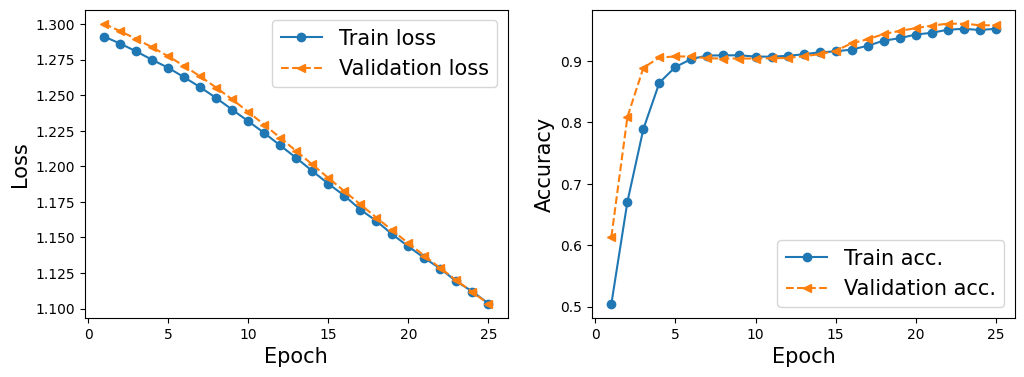

In [28]:
x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)

plt.show()

In [31]:
model.eval() 
all_preds = []  # Бинарные предсказания (0/1)
all_probs = []  # Вероятности (0.0-1.0)
all_labels = []  # Истинные метки (0/1)

with torch.no_grad():  
    for x_batch, y_batch in valid_dl:
        y_batch = y_batch.float().unsqueeze(1) 
        pred = model(x_batch) 
        
        binary_pred = (pred > 0.5).float().squeeze().numpy()
        
        prob = pred.squeeze().numpy()
        
        all_preds.extend(binary_pred)
        all_probs.extend(prob)
        all_labels.extend(y_batch.squeeze().numpy())

y_true = np.array(all_labels) 
y_pred = np.array(all_preds)      
y_prob = np.array(all_probs)     

In [32]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_prob)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")
print("\n" + "="*50)
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))

Accuracy:  0.9580
Precision: 0.7993
Recall:    0.7781
F1-score:  0.7886
ROC-AUC:   0.9726

              precision    recall  f1-score   support

     Class 0       0.98      0.98      0.98      2698
     Class 1       0.80      0.78      0.79       302

    accuracy                           0.96      3000
   macro avg       0.89      0.88      0.88      3000
weighted avg       0.96      0.96      0.96      3000



После чего имеем, что класс 1 необходимо улучшить в распозновании. Но модел реалистичная.